In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import joblib

from sklearn.metrics import r2_score, f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer

from nltk.stem import WordNetLemmatizer
import re

In [71]:
column_name = ['sentiment', 'id', 'date', 'query', 'user', 'text']

In [72]:
df = pd.read_csv('data.csv', encoding='ISO-8859-1', names=column_name)

In [73]:
df.head()

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [74]:
df.drop(['id', 'date', 'query', 'user'], axis=1, inplace=True)

In [75]:
df['sentiment'].value_counts()

0    800000
4    800000
Name: sentiment, dtype: int64

In [76]:
df['sentiment'] = df['sentiment'].replace(4, 1)

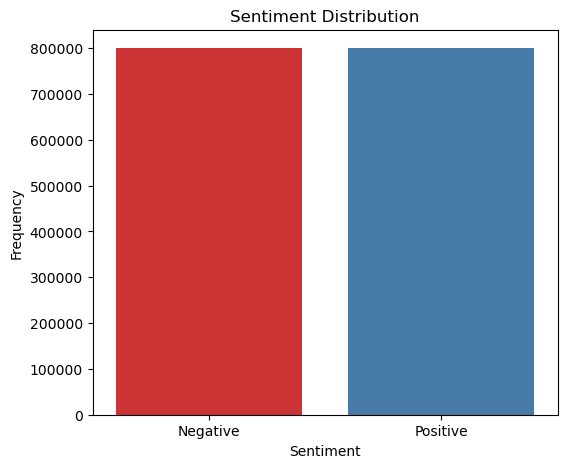

In [77]:
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(6, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set1')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.xticks(range(len(sentiment_counts)), ['Negative', 'Positive'])
plt.show()

In [78]:
df.isnull().sum()

sentiment    0
text         0
dtype: int64

In [79]:
def cleanText(text):
    cleanedText = []

    links = r'http\S+|www\S+|https\S+'
    userPattern = '@[^\s]+'
    apostrophe = r"'"
    nonWord = r'\W'
    singleCharacter = r'\s+[a-zA-Z]\s+'
    caretSymbol = r'\^[a-zA-Z]\s+'
    alphabet = "[^a-zA-Z0-9]"
    sequencePattern = r"(.)\1\1+"
    seqReplacePattern = r"\1\1"
    multiSpace = r'\s+'

    text = text.lower()

    text = re.sub(links, ' ', text, flags=re.MULTILINE)

    text = re.sub(userPattern,' ', text)
    text = re.sub(apostrophe, '', text)
    text = re.sub(nonWord, ' ', text)
    text = re.sub(singleCharacter, ' ', text)
    text = re.sub(caretSymbol, ' ', text) 
    text = re.sub(alphabet, " ", text)
    text = re.sub(sequencePattern, seqReplacePattern, text)
    
    text = re.sub(multiSpace, ' ', text, flags=re.I)
    
    wordLemm = WordNetLemmatizer()

    words = ''
    for word in text.split():
        if len(word)>1:
            if word != 'was':
                word = wordLemm.lemmatize(word)
            words += (word+' ')

    cleanedText.append(words)

    return " ".join(cleanedText)

In [80]:
df['text'] = df['text'].apply(lambda x: cleanText(x))

In [81]:
df.head()

,sentiment,text
0,0,thats bummer you shoulda got david carr of thi...
1,0,is upset that he cant update his facebook by t...
2,0,dived many time for the ball managed to save 5...
3,0,my whole body feel itchy and like it on fire
4,0,no it not behaving at all im mad why am here b...


In [84]:
from wordcloud import WordCloud

positive_texts = df[df['sentiment'] == 1]['text']
negative_texts = df[df['sentiment'] == 0]['text']

positive_text_combined = " ".join(text for text in positive_texts)
negative_text_combined = " ".join(text for text in negative_texts)

wordcloud_positive = WordCloud(max_font_size=100, max_words=500, background_color="black").generate(positive_text_combined)
wordcloud_negative = WordCloud(max_font_size=100, max_words=500, background_color="black").generate(negative_text_combined)

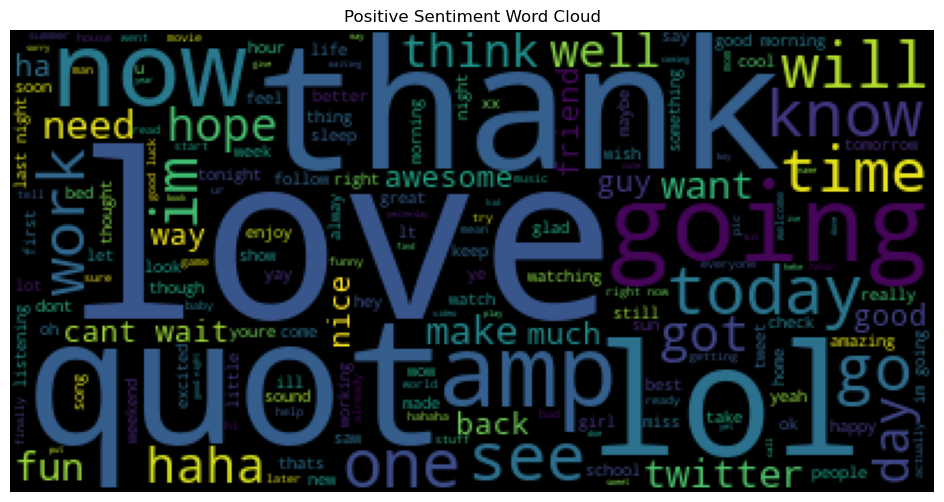

In [85]:
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_positive)
plt.title('Positive Sentiment Word Cloud')
plt.axis("off")
plt.show()

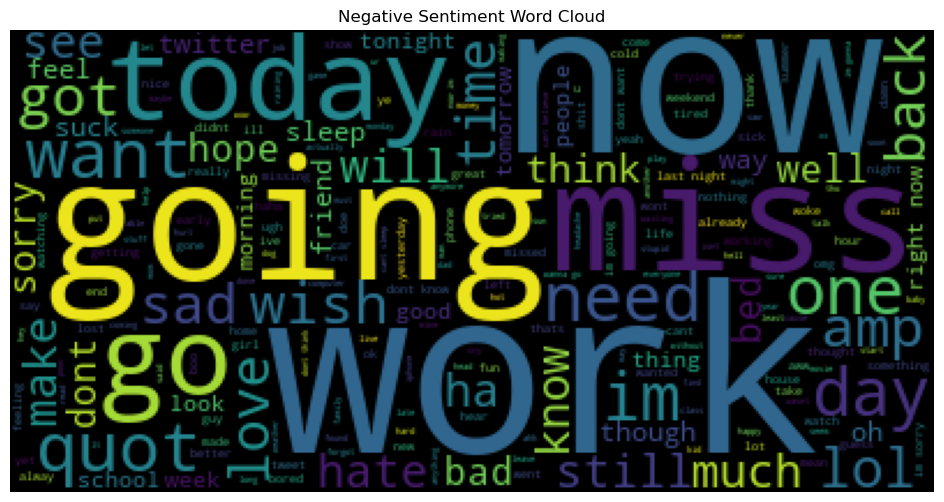

In [86]:
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_negative)
plt.title('Negative Sentiment Word Cloud')
plt.axis("off")
plt.show()

In [87]:
def get_top_ngrams(corpus, n=None, ngram_range=(2, 2)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

top_positive_bigrams = get_top_ngrams(positive_texts, n=10)
top_negative_bigrams = get_top_ngrams(negative_texts, n=10)

top_positive_bigrams, top_negative_bigrams

([('good morning', 8553),
  ('just got', 5833),
  ('im going', 4895),
  ('good luck', 3953),
  ('good night', 3889),
  ('looking forward', 3442),
  ('happy birthday', 3176),
  ('good day', 3021),
  ('great day', 2883),
  ('getting ready', 2830)],
 [('feel like', 6571),
  ('dont know', 6315),
  ('im going', 5943),
  ('im sorry', 5859),
  ('just got', 5550),
  ('dont want', 5143),
  ('look like', 4424),
  ('im gonna', 3987),
  ('dont think', 3403),
  ('im sad', 3020)])

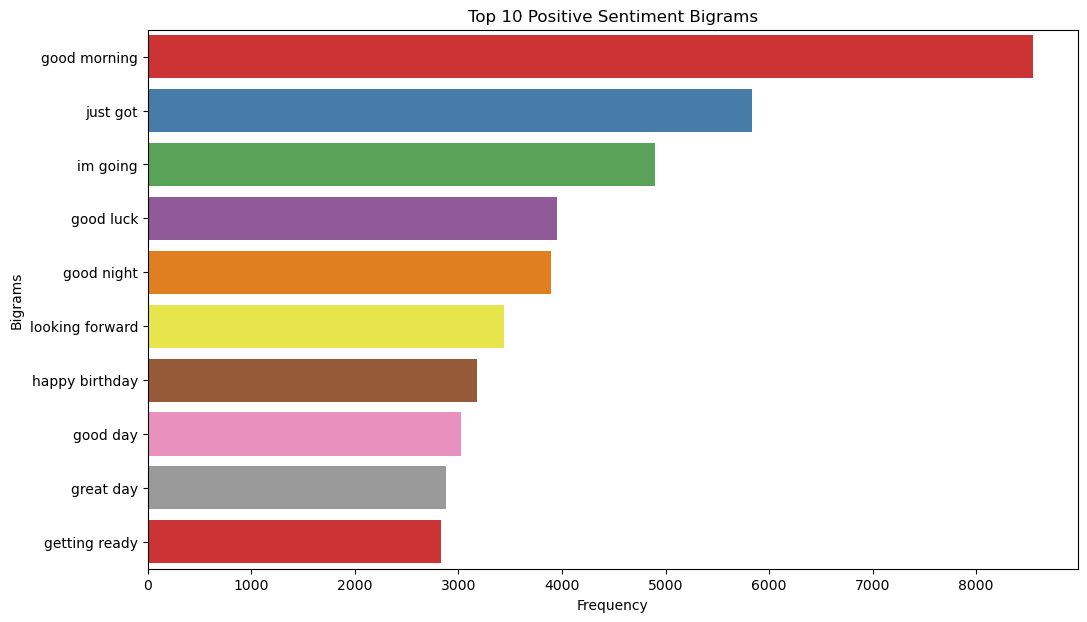

In [88]:
positive_bigrams, positive_counts = zip(*top_positive_bigrams)

plt.figure(figsize=(12, 7))

sns.barplot(x=list(positive_counts), y=list(positive_bigrams), palette='Set1')
plt.title('Top 10 Positive Sentiment Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigrams')

plt.show()

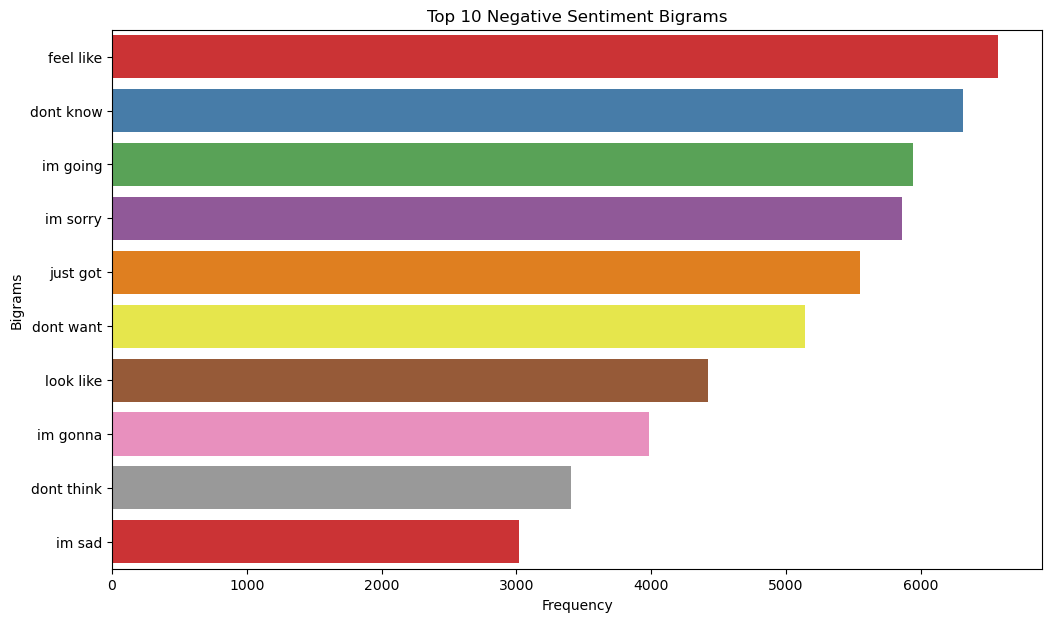

In [89]:
negative_bigrams, negative_counts = zip(*top_negative_bigrams)

plt.figure(figsize=(12, 7))

sns.barplot(x=list(negative_counts), y=list(negative_bigrams), palette='Set1')
plt.title('Top 10 Negative Sentiment Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigrams')

plt.show()

In [90]:
X = df['text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=92)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1280000,), (320000,), (1280000,), (320000,))

In [91]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=50000)

X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)

In [ ]:
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [92]:
scoreTrainArr = []
scoreTestArr = []

def pred_model(model):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    scoreTrain = accuracy_score(y_train, y_pred_train)
    scoreTest = accuracy_score(y_test, y_pred_test)
    
    scoreTrainArr.append(scoreTrain)
    scoreTestArr.append(scoreTest)
    
    print("=====================================================")
    print("Evaluasi Akurasi Model:")
    print("Training Accuracy :", scoreTrain)
    print("Testing Accuracy :", scoreTest)
    
    print("=====================================================")
    
    print("\nClassification report untuk data test:")
    cr = classification_report(y_test, y_pred_test)
    print(cr)
    
    print("=====================================================")
    print('F1 Score: ', f1_score(y_test,y_pred_test))
    print("=====================================================")
    
    confusion_matrix_percent = confusion_matrix(y_test, y_pred_test) / len(y_test)
    confusion_matrix_df = pd.DataFrame(confusion_matrix_percent, ('Negative', 'Positive'), ('Negative', 'Positive'))

    plt.figure()
    heatmap = sns.heatmap(confusion_matrix_df, annot=True, annot_kws={'size': 14}, fmt='.2f', cmap='YlGnBu')
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0,  fontsize=14)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=0,  fontsize=14)

    plt.title('Confusion Matrix untuk Data Test', fontsize=18, color='darkblue')
    plt.ylabel('True label', fontsize=14)
    plt.xlabel('Predicted label', fontsize=14)
    plt.show()

c:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Evaluasi Akurasi Model:
Training Accuracy : 0.83419765625
Testing Accuracy : 0.820675

Classification report untuk data test:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82    160202
           1       0.81      0.83      0.82    159798

    accuracy                           0.82    320000
   macro avg       0.82      0.82      0.82    320000
weighted avg       0.82      0.82      0.82    320000

F1 Score:  0.8224889411327992


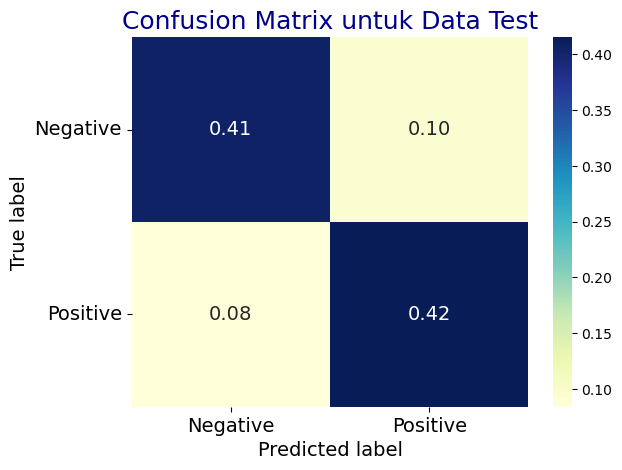

In [93]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
pred_model(logreg)

Evaluasi Akurasi Model:
Training Accuracy : 0.7962171875
Testing Accuracy : 0.7912375

Classification report untuk data test:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79    160202
           1       0.78      0.81      0.79    159798

    accuracy                           0.79    320000
   macro avg       0.79      0.79      0.79    320000
weighted avg       0.79      0.79      0.79    320000

F1 Score:  0.7949312999594799


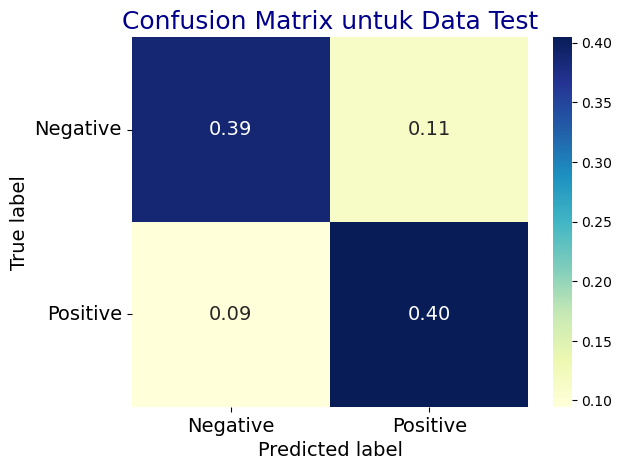

In [94]:
bnb = BernoulliNB(alpha=2)
bnb.fit(X_train, y_train)
pred_model(bnb)

Evaluasi Akurasi Model:
Training Accuracy : 0.7733828125
Testing Accuracy : 0.76871875

Classification report untuk data test:
              precision    recall  f1-score   support

           0       0.80      0.72      0.76    160202
           1       0.74      0.82      0.78    159798

    accuracy                           0.77    320000
   macro avg       0.77      0.77      0.77    320000
weighted avg       0.77      0.77      0.77    320000

F1 Score:  0.7793802017504113


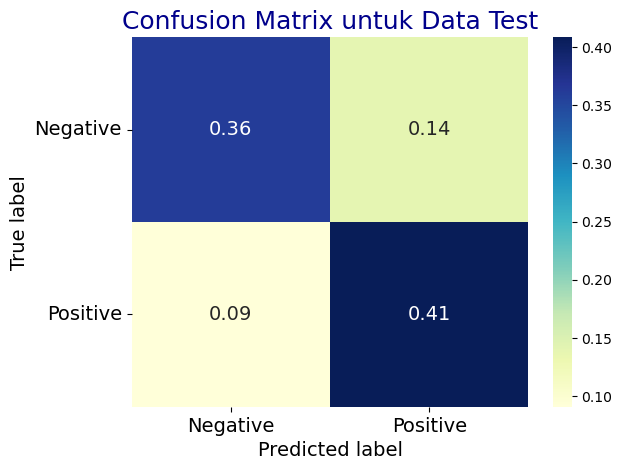

In [100]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
pred_model(xgb)

In [102]:
nama_model = ['Logistic Regression', 'Bernoulli Naive Bayes', 'XGBoost']

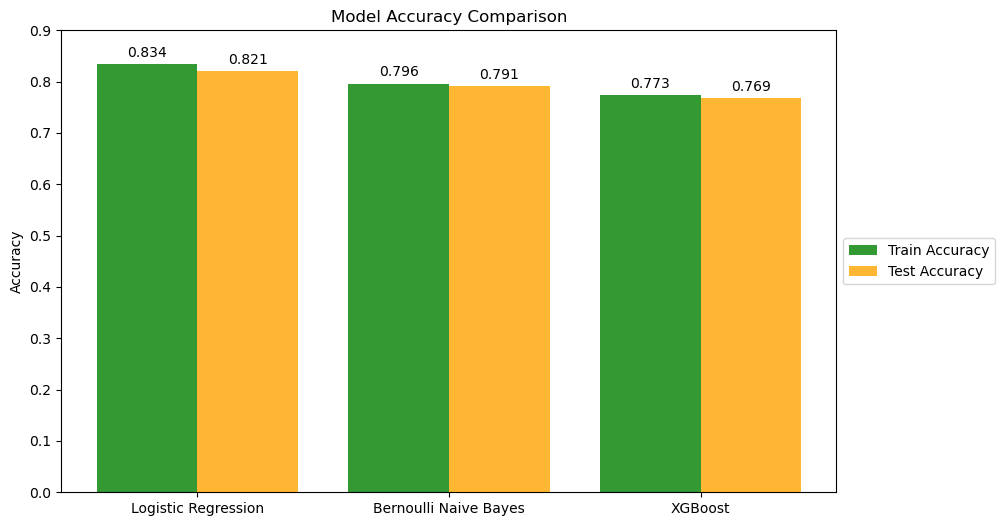

In [107]:
fig, ax = plt.subplots(figsize=(10, 6))

# Lebar setiap bar
bar_width = 0.4

# Array untuk sumbu x
x_pos = np.arange(len(nama_model))

# Plot untuk akurasi train
train_bars = ax.bar(x_pos, scoreTrainArr, width=bar_width, align='center', alpha=0.8, label='Train Accuracy', color='green')

# Plot untuk akurasi test
test_bars = ax.bar(x_pos + bar_width, scoreTestArr, width=bar_width, align='center', alpha=0.8, label='Test Accuracy', color='orange')

ax.set_xticks(x_pos + bar_width / 2)
ax.set_xticklabels(nama_model)

ax.set_ylabel('Accuracy')

ax.set_title('Model Accuracy Comparison')

# Untuk memberikan annotation di setiap puncak bar
for bar1, bar2 in zip(train_bars, test_bars):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    ax.annotate(f'{height1:.3f}', xy=(bar1.get_x() + bar1.get_width() / 2, height1),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom')
    ax.annotate(f'{height2:.3f}', xy=(bar2.get_x() + bar2.get_width() / 2, height2),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom')

ax.set_ylim(0, 0.9)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

In [95]:
with open('sentiment_model.pickle', 'wb') as f:
    pickle.dump(logreg, f)

In [96]:
with open('sentiment_model.pickle', 'rb') as f:
    model = pickle.load(f)

In [97]:
def predict_sentiment(text):
    cleaned_text = cleanText(text)

    text_vectorized = tfidf_vectorizer.transform([cleaned_text])

    sentiment_prediction = model.predict(text_vectorized)

    sentiment_label = 'Positive' if sentiment_prediction[0] == 1 else 'Negative'

    return sentiment_label

In [98]:
predict_sentiment("I like Christmas because people enjoy holiday")

'Positive'

In [99]:
predict_sentiment("Budi doesn't like cheap gift")

'Negative'